# 09 – Feature Representation Analysis

## Goal

Throughout this project, we used several different audio representations:

- Waveforms
- Spectrograms
- Mel-Spectrograms
- MFCCs

Each representation captures different aspects of an audio signal and is suited for different machine learning tasks.

The goal of this notebook is to compare these representations, understand their strengths and limitations, and explain why different models benefit from different feature types.

In [7]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [12]:
data_path = Path("../data/raw/gtzan/Data/genres_original")

song = data_path / "rock" / "rock.00000.wav"

y, sr = librosa.load(song, sr=22050)

print("Duration:", len(y)/sr)

Duration: 30.013333333333332


## 1. Waveform – The Raw Audio Signal

The waveform is the most fundamental representation of an audio signal.

It contains every recorded sample and therefore preserves all available information.

However, because it only represents amplitude over time, it is difficult for humans and many classical machine learning algorithms to interpret directly.

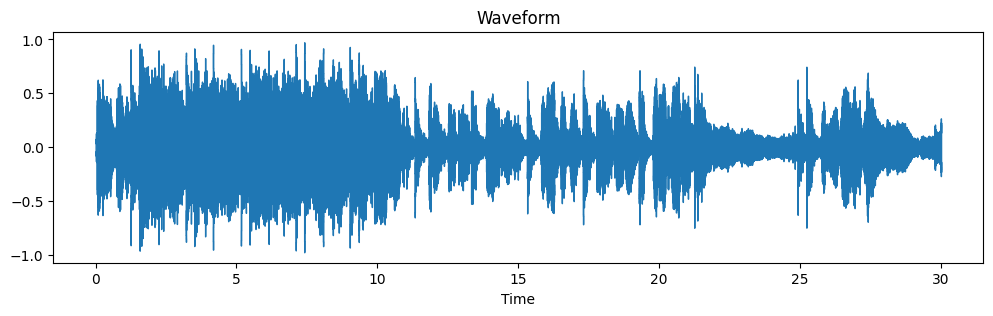

In [13]:
plt.figure(figsize=(12,3))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")
plt.show()

## 2. Spectrogram – Adding Frequency Information

A spectrogram transforms the waveform into the frequency domain using the Short-Time Fourier Transform (STFT).

Unlike the waveform, it reveals how frequency components evolve over time.

This representation already provides much more meaningful information for audio analysis

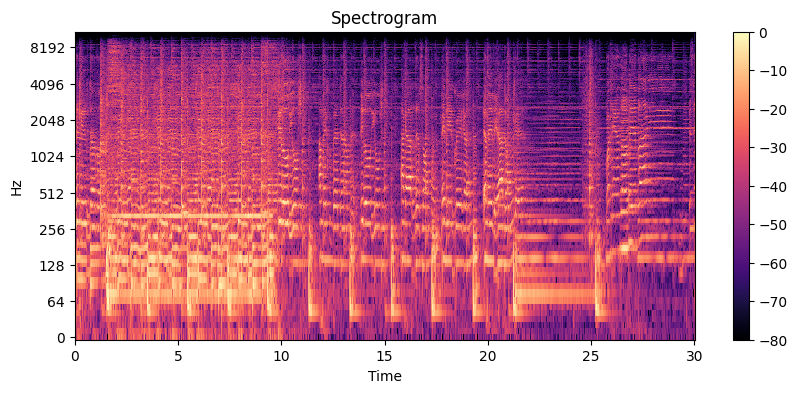

In [14]:
D = librosa.amplitude_to_db(
    np.abs(librosa.stft(y)),
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    D,
    sr=sr,
    x_axis="time",
    y_axis="log"
)

plt.colorbar()
plt.title("Spectrogram")
plt.show()

## 3. MFCC Features

MFCCs (Mel-Frequency Cepstral Coefficients) compress the spectral information of an audio signal into a small number of descriptive features.

Instead of preserving the entire spectrogram, they summarize its overall spectral characteristics.

This compact representation makes MFCCs highly suitable for classical machine learning algorithms such as Random Forests.

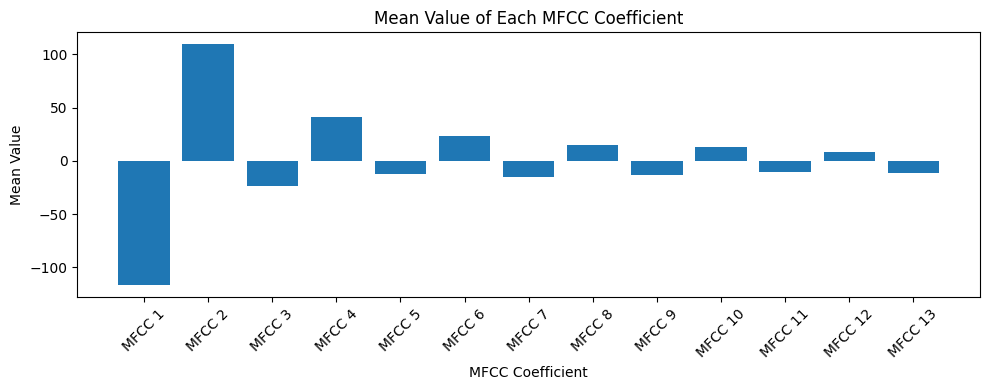

In [24]:
plt.figure(figsize=(10,4))
plt.bar(mfcc_feature_names, mfcc_means)

plt.title("Mean Value of Each MFCC Coefficient")
plt.xlabel("MFCC Coefficient")
plt.ylabel("Mean Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## What Do the MFCC Coefficients Represent?

MFCCs are compact features that mainly represent timbre, meaning the general sound color or texture of the audio.

Each MFCC coefficient captures a different aspect of the spectral envelope.

- Lower-order coefficients describe the overall shape of the spectrum.
- Higher-order coefficients capture finer spectral details.

In this project, we use the first 13 coefficients because they contain most of the perceptually relevant information while keeping the feature vector compact.

For machine learning, the MFCCs are summarized over time by calculating the mean value of each coefficient.  
In the recommendation system, both the mean and standard deviation of each MFCC coefficient are used, resulting in 26 features per song.

MFCCs are useful because they strongly reduce the dimensionality of the audio signal while still preserving important sound characteristics.

## 4. Mel-Spectrogram vs. MFCC

Although both representations are derived from the Mel scale, they preserve different amounts of information.

The Mel-spectrogram retains the complete time–frequency representation.

MFCCs compress this information into a much smaller feature vector.

This illustrates the trade-off between information richness and computational efficiency.

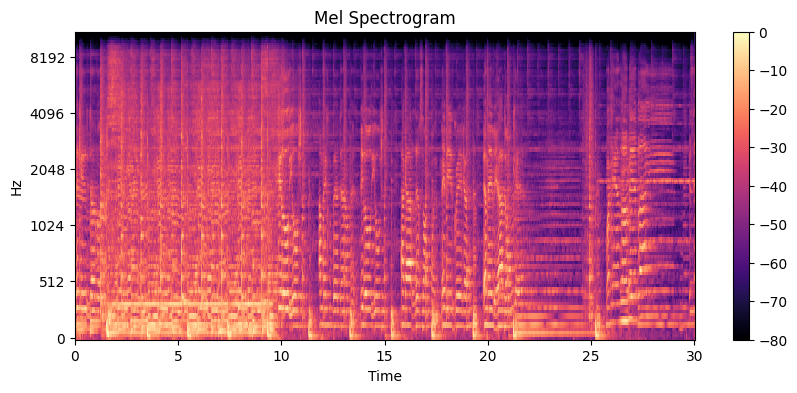

In [15]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

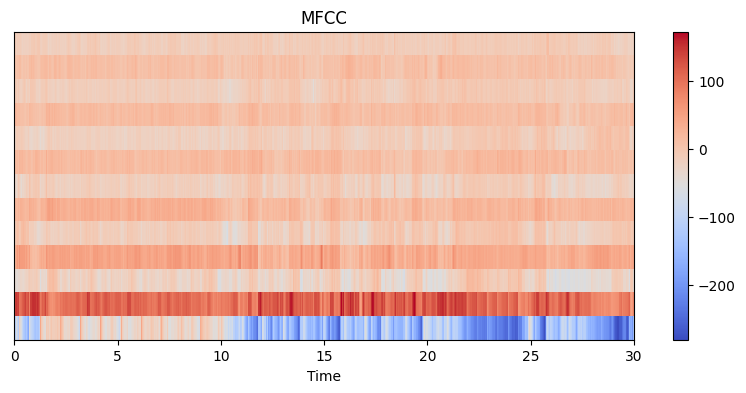

In [16]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC")
plt.show()

In [23]:
mfcc_feature_names = [f"MFCC {i+1}" for i in range(mfcc.shape[0])]

mfcc_means = np.mean(mfcc, axis=1)
mfcc_stds = np.std(mfcc, axis=1)

for name, mean, std in zip(mfcc_feature_names, mfcc_means, mfcc_stds):
    print(f"{name}: mean={mean:.2f}, std={std:.2f}")

MFCC 1: mean=-116.63, std=76.46
MFCC 2: mean=109.25, std=22.03
MFCC 3: mean=-23.16, std=19.21
MFCC 4: mean=40.68, std=12.69
MFCC 5: mean=-11.89, std=13.99
MFCC 6: mean=23.15, std=11.28
MFCC 7: mean=-15.41, std=11.41
MFCC 8: mean=15.12, std=7.98
MFCC 9: mean=-13.52, std=10.57
MFCC 10: mean=12.70, std=7.69
MFCC 11: mean=-10.87, std=8.79
MFCC 12: mean=8.50, std=7.39
MFCC 13: mean=-11.58, std=6.25


## Comparing Feature Dimensions

Different representations vary considerably in size.

Comparing their dimensions illustrates how much information is retained—or compressed—at each stage of the processing pipeline.

In [17]:
print("Waveform:", y.shape)
print("Spectrogram:", D.shape)
print("Mel:", mel_db.shape)
print("MFCC:", mfcc.shape)

Waveform: (661794,)
Spectrogram: (1025, 1293)
Mel: (128, 1293)
MFCC: (13, 1293)


## 5. Similarity Analysis Using MFCCs

MFCC feature vectors can be compared using cosine similarity.

Rather than comparing raw waveforms, we compare compact feature representations that capture the timbral characteristics of each song.

This principle forms the foundation of the recommendation system developed in Week 8.

### Cosine Similarity

To compare songs, we measure the similarity between their MFCC feature vectors using cosine similarity.

Instead of comparing the magnitude of the vectors, cosine similarity compares their direction in the feature space.

The similarity score ranges from:

- **1** → identical feature direction (very similar)
- **0** → unrelated feature vectors
- **-1** → opposite feature direction

Because MFCC vectors describe the spectral characteristics of songs, cosine similarity provides a simple way to estimate how acoustically similar two songs are.

In [18]:
song1 = data_path / "rock" / "rock.00000.wav"
song2 = data_path / "rock" / "rock.00005.wav"

def mfcc_vector(file):

    y, sr = librosa.load(file, sr=22050)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    return np.mean(mfcc, axis=1)

v1 = mfcc_vector(song1)
v2 = mfcc_vector(song2)

similarity = cosine_similarity(
    [v1],
    [v2]
)

print("Cosine similarity:", similarity[0][0])

Cosine similarity: 0.8989313


In [19]:
song3 = data_path / "classical" / "classical.00000.wav"

v3 = mfcc_vector(song3)

similarity = cosine_similarity(
    [v1],
    [v3]
)

print(similarity[0][0])

0.93722796



The similarity scores show that MFCC-based similarity does not always directly match genre similarity.  
In this example, a song from another genre can appear more similar than a song from the same genre.  
This highlights that MFCCs mainly capture timbral characteristics, while genre also depends on rhythm, harmony, instrumentation, and musical structure.

Although genre labels are not used directly, the extracted features already capture meaningful acoustic similarities.

Cosine similarity focuses on the overall shape of the feature vectors rather than their absolute values.

This makes it particularly useful when comparing audio features that may vary in magnitude but share similar spectral characteristics.

## 6. Visualizing the Feature Space

The extracted MFCC feature vectors originally exist in a 13-dimensional space.

To visualize their relationships, we apply Principal Component Analysis (PCA), reducing the data to two dimensions while preserving as much variance as possible.

Songs that appear close together in the projection have similar MFCC representations.

In [20]:
features = []
labels = []

for genre in ["rock","classical","jazz","metal"]:

    files = list((data_path/genre).glob("*.wav"))[:20]

    for file in files:

        features.append(mfcc_vector(file))
        labels.append(genre)

features = np.array(features)

In [21]:
pca = PCA(n_components=2)

projection = pca.fit_transform(features)

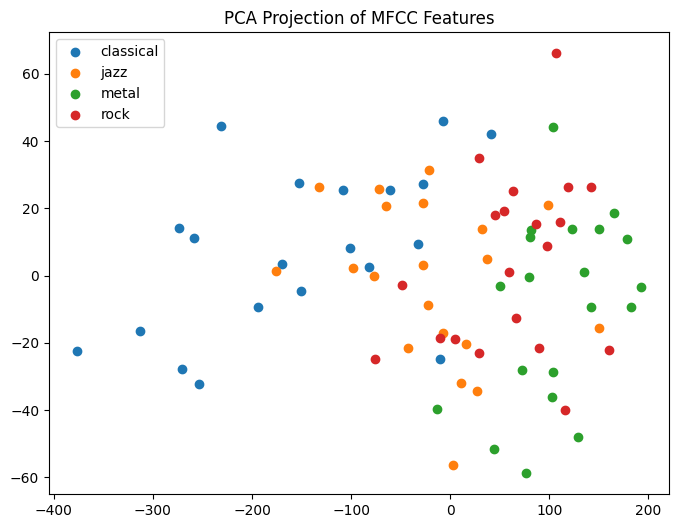

In [22]:
plt.figure(figsize=(8,6))

for genre in np.unique(labels):

    idx = np.array(labels)==genre

    plt.scatter(
        projection[idx,0],
        projection[idx,1],
        label=genre
    )

plt.legend()

plt.title("PCA Projection of MFCC Features")

plt.show()

The remaining overlap also illustrates why genre classification is a challenging task.

Not all genres can be separated perfectly using MFCC features alone.

Although some overlap remains, the visualization demonstrates that MFCC features already provide meaningful separation between genres.

## Selecting the Appropriate Feature Representation

Throughout this project, different representations were chosen depending on the machine learning task.

The table below summarizes these design decisions.

| Representation | Strength | Used For |
|---------------|----------|----------|
| Waveform | Complete raw signal | Basic visualization |
| Spectrogram | Frequency analysis | Signal inspection |
| Mel-Spectrogram | Rich time–frequency representation | CNN classification |
| MFCC | Compact feature vector | Random Forest & Recommendation System |

There is no universally "best" representation.

Instead, the choice depends on the machine learning task and the balance between computational efficiency and information content.

## Observations

- Each representation captures different aspects of the audio signal.
- Waveforms preserve all information but are difficult to interpret directly.
- Spectrograms reveal frequency structures over time.
- Mel-spectrograms retain rich time–frequency information while approximating human hearing.
- MFCCs provide a compact summary of spectral characteristics.
- Songs from the same genre generally exhibit higher MFCC similarity.
- PCA shows that MFCC features already separate genres reasonably well.
- The choice of feature representation strongly influences downstream machine learning performance.

## Interpretation

The cosine similarity results show that MFCC representations do not always align with genre labels.

In some cases, a song from a different genre exhibits a higher similarity score than another song from the same genre.

This suggests that MFCCs capture timbral similarity rather than semantic concepts such as genre.

While this behavior can be beneficial for recommendation systems, it also highlights a limitation of MFCCs for genre classification.

## Reflection

In this notebook, similarity is computed using handcrafted MFCC features.

However, the CNN developed in Week 6 learned its own internal feature representations directly from Mel-spectrograms.

These learned representations are likely to capture more complex musical characteristics than MFCCs alone.

An interesting extension of this project would therefore be to use the CNN embeddings instead of MFCCs for song recommendation.

This could potentially improve recommendation quality by comparing songs based on features learned automatically from the data.

## Week 9 Summary

This notebook compared the feature representations used throughout the project.

We:

- analyzed waveforms, spectrograms, Mel-spectrograms, and MFCCs
- compared their dimensions and information content
- examined MFCC coefficients in more detail
- measured similarity between songs using cosine similarity
- visualized the feature space using PCA

The analysis demonstrates that no single representation is universally optimal. Instead, the appropriate choice depends on the machine learning task and the trade-off between computational efficiency and information richness.

### Key Takeaway

The experiments in this notebook show that feature representation is one of the most important design choices in audio machine learning.

Rather than searching for a universally "best" representation, it is more useful to select the representation that best matches the task.

In this project:

- MFCCs proved to be efficient for classical machine learning and recommendation.
- Mel-spectrograms enabled more expressive deep learning models.
- CNN-learned representations may provide an even stronger basis for future recommendation systems.